## Exercício 1 — Log loss: o preço da confiança errada

Dois modelos (A e B) preveem os mesmos 5 exemplos.

**(a)** Os dois têm a MESMA acurácia. Por que o **log loss** difere?

**(b)** Qual modelo é preferível e por quê?

**(c)** Olhando a **perda por exemplo** de B, qual exemplo mais pesa no log loss? Explique com o valor.

acuracia A: 0.8  | acuracia B: 0.8
log loss A: 0.435  | log loss B: 0.808
ex0: y=1 pB=0.8 perda=0.22
ex1: y=0 pB=0.4 perda=0.51
ex2: y=1 pB=0.7 perda=0.36
ex3: y=0 pB=0.93 perda=2.66
ex4: y=1 pB=0.75 perda=0.29


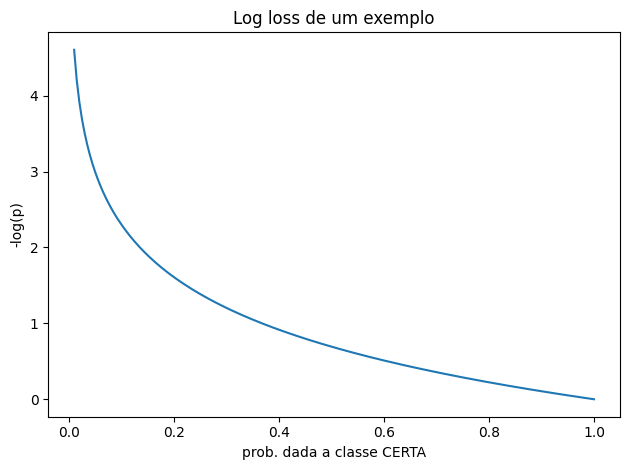

In [2]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import log_loss, accuracy_score
df=pd.read_csv("ex4_modelos.csv"); y=df["y"].values; pA=df["pA"].values; pB=df["pB"].values
predA=(pA>=0.5).astype(int); predB=(pB>=0.5).astype(int)
print("acuracia A:",accuracy_score(y,predA)," | acuracia B:",accuracy_score(y,predB))
print("log loss A:",round(log_loss(y,pA),3)," | log loss B:",round(log_loss(y,pB),3))
# perda de cada exemplo do modelo B:  -log(prob. dada a classe CERTA)
perdaB = -np.log(np.where(y==1, pB, 1-pB))
for i,(yy,pp,perda) in enumerate(zip(y,pB,perdaB)): print(f"ex{i}: y={yy} pB={pp} perda={perda:.2f}")
p=np.linspace(0.01,1,200); plt.plot(p,-np.log(p)); plt.xlabel("prob. dada a classe CERTA"); plt.ylabel("-log(p)"); plt.title("Log loss de um exemplo"); plt.tight_layout(); plt.show()

*Resposta:A


Ambos os modelos (A e B) têm uma acurácia de 0.8. No entanto, o log loss do Modelo A é 0.435 e o do Modelo B é 0.808. O log loss penaliza severamente previsões incorretas com alta confiança. Embora ambos os modelos errem o mesmo número de vezes, o Modelo B fez uma previsão errada com *muita confiança* para o exemplo 3 (previu 0.93 para y=0), o que resultou em uma perda muito alta (2.66) para este exemplo, elevando significativamente o log loss total do Modelo B.

Resposta B

O Modelo A é preferível. Embora a acurácia seja a mesma, o Modelo A tem um log loss menor (0.435). Isso indica que suas probabilidades são mais bem calibradas e menos 'confiantemente erradas' do que as do Modelo B. Em cenários onde a confiança das previsões importa (não apenas o acerto ou erro), um log loss menor é um indicador de um modelo superior.

---

Resposta: C

O exemplo que mais pesa no log loss do Modelo B é o **exemplo 3**, com uma perda de **2.66**. Isso ocorre porque a classe real (`y`) era 0, mas o Modelo B atribuiu uma probabilidade muito alta de 0.93 à classe 1, mostrando uma alta confiança em uma previsão incorreta.

## Exercício 2 — Limiar, matriz de confusão e ROC

O gráfico mostra a nota de 15 emails (cor = spam real ou não) com o limiar em **0,5** (spam = positivo).

**(a)** Com o limiar 0,5, defina VP, VN, FP e FN.

**(b)** O ideal é o **maior recall possível**. O que fazer com o limiar? Explique.

**(c)** Avalie a **ROC/AUC**: o que ela representa e o que faria a curva melhorar?

**(d)** Agora suba o limiar para **0,7**: dê os **novos VP, FP e FN** e **recalcule precisão e recall**. Compare com o de 0,5.

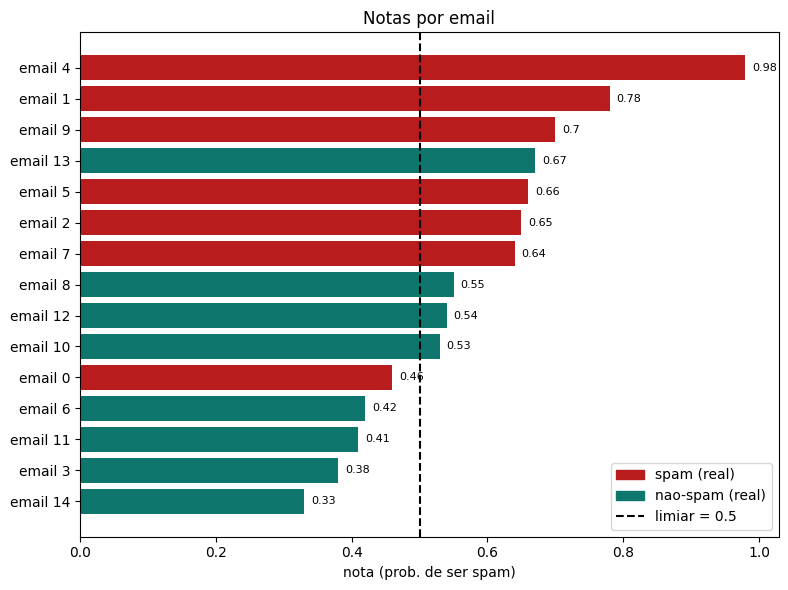

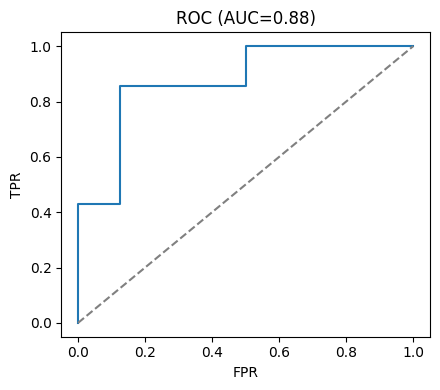

In [3]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import matplotlib.patches as mp
from sklearn.metrics import roc_curve, auc
df=pd.read_csv("ex3_emails.csv"); nota=df["nota"].values; spam=df["spam"].values; m=len(df)
lim=0.5; ordem=np.argsort(nota)
plt.figure(figsize=(8,6))
cores=["#B91C1C" if s==1 else "#0F766E" for s in spam[ordem]]
plt.barh(range(m), nota[ordem], color=cores); plt.axvline(lim, ls="--", color="black")
plt.yticks(range(m), [f"email {i}" for i in ordem])
for i,v in enumerate(nota[ordem]): plt.text(v+0.01,i,str(v),va="center",fontsize=8)
plt.legend(handles=[mp.Patch(color="#B91C1C",label="spam (real)"),mp.Patch(color="#0F766E",label="nao-spam (real)"),
                    plt.Line2D([0],[0],ls="--",color="black",label="limiar = 0.5")], loc="lower right")
plt.xlabel("nota (prob. de ser spam)"); plt.title("Notas por email"); plt.tight_layout(); plt.show()
fpr,tpr,_=roc_curve(spam,nota); a=auc(fpr,tpr)
plt.figure(figsize=(4.5,4)); plt.plot(fpr,tpr); plt.plot([0,1],[0,1],"--",color="gray"); plt.title(f"ROC (AUC={a:.2f})"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.tight_layout(); plt.show()

Resposta:

**(a) Com o limiar 0,5, defina VP, VN, FP e FN.**
*   **Limiar = 0.5**
    *   **VP (Verdadeiros Positivos):** Emails classificados como spam (nota > 0.5) e que são spam na realidade (cor vermelha). Olhando o gráfico, são eles: email 4 (0.98), email 1 (0.78), email 9 (0.7), email 5 (0.66), email 2 (0.65), email 7 (0.64).
        *   **VP = 6**
    *   **VN (Verdadeiros Negativos):** Emails classificados como não-spam (nota <= 0.5) e que são não-spam na realidade (cor verde). São eles: email 3 (0.38), email 11 (0.41), email 6 (0.42).
        *   **VN = 3**
    *   **FP (Falsos Positivos):** Emails classificados como spam (nota > 0.5) mas que são não-spam na realidade (cor verde). São eles: email 13 (0.67), email 8 (0.55), email 12 (0.54), email 10 (0.53).
        *   **FP = 4**
    *   **FN (Falsos Negativos):** Emails classificados como não-spam (nota <= 0.5) mas que são spam na realidade (cor vermelha). É ele: email 0 (0.46).
        *   **FN = 1**



 ---

 Resposta B:       

Para ter o maior recall possível, a gente tem que diminuir o limiar!

 pensando da seguinrte forma:  o recall mede quantos spams de verdade nosso modelo conseguiu pegar. Se a gente quer pegar o máximo de spam e não deixar nenhum passar "batido", (minimizar os Falsos Negativos), faz sentido 'afrouxar' um pouco a régua do que consideramos spam. Diminuindo o limiar, mais e-mails vão ser classificados como spam, o que aumenta nossos Verdadeiros Positivos (spams que a gente acertou). Por exemplo, aquele e-mail 0, que é spam mas tinha nota 0.46: se o limiar fosse 0.45, ele seria pego, virando um VP e ajudando a aumentar o recall!

 --


Resposta C:


A Curva ROC (Receiver Operating Characteristic) plota a Taxa de Verdadeiros Positivos (TPR, ou recall) versus a Taxa de Falsos Positivos (FPR) em vários limiares de classificação. Ela mostra a capacidade de um modelo de distinguir entre as classes. A **AUC (Área Sob a Curva)** quantifica essa performance geral do modelo; um valor de 0.88 é considerado bom, indicando que o modelo tem uma boa capacidade de separação entre spam e não-spam.

A curva ROC melhoraria (ficaria mais próxima do canto superior esquerdo do gráfico, e a AUC aumentaria) se o modelo fosse capaz de fazer uma distinção ainda mais clara entre os emails de spam e não-spam. Isso significa que, para o mesmo nível de Falsos Positivos, o modelo conseguiria identificar mais Verdadeiros Positivos. Isso geralmente é alcançado com um modelo mais sofisticado ou com a incorporação de mais características relevantes para a classificação.


---


Resposta D:


*   Limiar = 0.7

    *   *P: Emails vermelhos com nota > 0.7: email 4 (0.98), email 1 (0.78).
        *   **VP = 2**


    *   **FP:** Emails verdes com nota > 0.7: Nenhum.
        *   **FP = 0**

    *   **FN:** Emails vermelhos com nota <= 0.7: email 0 (0.46), email 9 (0.7), email 5 (0.66), email 2 (0.65), email 7 (0.64).

        *  FN = 5



    *   Cálculo das métricas para limiar 0.7:

        *   Total de emails de spam reais = VP + FN = 2 + 5 = 7 (Note que este valor é consistente com o total de spams reais no conjunto de dados, que é 7).

        *   **Recall = VP / (VP + FN)** = 2 / (2 + 5) = 2 / 7 ≈ **0.286**
        *   **Precisão = VP / (VP + FP)** = 2 / (2 + 0) = 2 / 2 = **1.0**

   -----     

    *   Comparação com limiar 0.5:

        *   Limiar 0.5:*Recall ≈ 0.857 (6/7), Precisão ≈ 0.6 (6/10).
        *   Limiar 0.7: Recall ≈ 0.286, Precisão = 1.0.


    *   Ao subir o limiar de 0.5 para 0.7, o **recall diminuiu significativamente** (de ~0.86 para ~0.29). Isso significa que o modelo deixou de identificar muitos spams reais. Por outro lado, a **precisão aumentou drasticamente** (de ~0.6 para 1.0), indicando que, dos poucos emails classificados como spam, todos eram realmente spam. Esta é uma troca comum entre precisão e recall ao ajustar o limiar: aumentar a precisão geralmente diminui o recall, e vice-versa.

## Exercício 3 — Acurácia alta = modelo bom?

O código dá VP, VN, FP, FN (limiar 0,5), a proporção de positivos e as curvas ROC e PR.

**(a)** Calcule **acurácia**, **recall** e **precisão** a partir de VP, VN, FP e FN.

**(b)** O desenvolvedor disse que o modelo é bom **porque a acurácia é alta**. Ele está certo? Justifique usando a **proporção de positivos** e o que a ROC e a PR mostram.

**(c)** Se o modelo passasse a acertar **2 dos FN** (viram VP), qual seria o **novo recall**? Mostre a conta.

VP = 42 | FP = 223 | FN = 16 | VN = 719 | N = 1000
proporcao de positivos (reais): 0.058


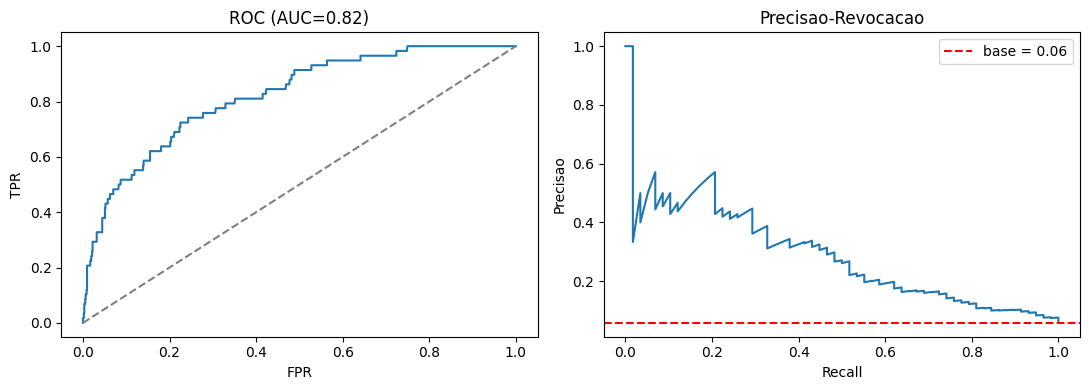

In [4]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
df = pd.read_csv("ex2_classificacao.csv"); y=df["y_real"].values; score=df["score"].values
pred=(score>=0.5).astype(int)
VP=int(((pred==1)&(y==1)).sum()); FP=int(((pred==1)&(y==0)).sum())
FN=int(((pred==0)&(y==1)).sum()); VN=int(((pred==0)&(y==0)).sum())
print("VP =",VP,"| FP =",FP,"| FN =",FN,"| VN =",VN,"| N =",len(y))
print("proporcao de positivos (reais):", round(y.mean(),3))
fpr,tpr,_=roc_curve(y,score); prec,rec,_=precision_recall_curve(y,score)
fig,ax=plt.subplots(1,2,figsize=(11,4))
ax[0].plot(fpr,tpr); ax[0].plot([0,1],[0,1],"--",color="gray"); ax[0].set_title(f"ROC (AUC={auc(fpr,tpr):.2f})"); ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR")
ax[1].plot(rec,prec); ax[1].axhline(y.mean(),ls="--",color="red",label=f"base = {y.mean():.2f}"); ax[1].set_title("Precisao-Revocacao"); ax[1].set_xlabel("Recall"); ax[1].set_ylabel("Precisao"); ax[1].legend()
plt.tight_layout(); plt.show()

Resposta A :

Dados iniciais (limiar 0,5):
VP = 42 | FP = 223 | FN = 16 | VN = 719 | N = 1000
Proporção de positivos (reais): 0.058

**(a) Calcule acurácia, recall e precisão a partir de VP, VN, FP e FN.**
*   **Acurácia = (VP + VN) / N**
    *   Acurácia = (42 + 719) / 1000 = 761 / 1000 = **0.761**
*   **Recall = VP / (VP + FN)**
    *   Recall = 42 / (42 + 16) = 42 / 58 = **0.724** (aproximadamente)
*   **Precisão = VP / (VP + FP)**
    *   Precisão = 42 / (42 + 223) = 42 / 265 = **0.158** (aproximadamente)

  
  -----  

Resposta B:

O desenvolvedor **não está certo**. Embora a acurácia de 0.761 possa parecer razoável isoladamente, ela é enganosa neste contexto. A proporção de positivos é muito baixa (0.058 ou 5.8%), indicando um conjunto de dados desbalanceado. Um modelo ingênuo que sempre previsse a classe majoritária (negativo) teria uma acurácia de 1 - 0.058 = 0.942, que é significativamente MAIOR que a acurácia do modelo (0.761). Isso mostra que a acurácia por si só não é uma métrica adequada aqui.

A curva ROC (AUC=0.82) sugere que o modelo tem alguma capacidade de distinguir as classes, mas a curva de Precisão-Revocação (PR) é mais reveladora para classes desbalanceadas. A precisão do modelo (0.158) é bem baixa, indicando que a maioria das previsões positivas feitas pelo modelo são, na verdade, falsos positivos. Embora a curva PR esteja acima da linha de base (que é a proporção de positivos, 0.058), ela não mostra uma performance excepcional para identificar a classe minoritária. Portanto, o modelo não é

## Exercício 4 — Overfitting × underfitting

A acurácia de treino e teste por profundidade da árvore.

**(a)** Aponte a região de **underfitting** e a de **overfitting**.

**(b)** O que acontece com treino e teste em cada região?

**(c)** Qual complexidade você escolheria e por quê?

**(d)** A partir de qual profundidade o **vão treino−teste** começa a se abrir, e o que isso indica?

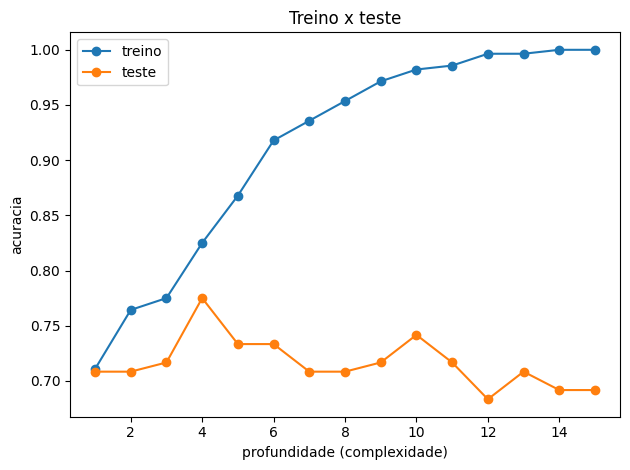

melhor profundidade no teste: 4


In [5]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
df=pd.read_csv("ex6_dados.csv"); X=df[[f"f{i}" for i in range(1,7)]]; y=df["y"]
Xtr,Xte,ytr,yte=train_test_split(X,y,test_size=0.3,random_state=0,stratify=y)
prof=range(1,16); tr=[]; te=[]
for d in prof:
    m=DecisionTreeClassifier(max_depth=d,random_state=0).fit(Xtr,ytr)
    tr.append(accuracy_score(ytr,m.predict(Xtr))); te.append(accuracy_score(yte,m.predict(Xte)))
plt.plot(list(prof),tr,marker="o",label="treino"); plt.plot(list(prof),te,marker="o",label="teste")
plt.xlabel("profundidade (complexidade)"); plt.ylabel("acuracia"); plt.legend(); plt.title("Treino x teste"); plt.tight_layout(); plt.show()
print("melhor profundidade no teste:", list(prof)[int(np.argmax(te))])

REesposta A:


Região de Underfitting:Corresponde às baixas complexidades (profundidade da árvore). No gráfico, isso seria aproximadamente nas profundidades 1 a 2, onde tanto a acurácia de treino quanto a de teste são relativamente baixas e estão bem próximas.

Região de Overfitting: Começa a se manifestar quando a profundidade é maior que a ideal. A partir de uma profundidade **5-6 em diante**, a acurácia de treino continua subindo e atinge o máximo (1.0), enquanto a acurácia de teste começa a estagnar ou diminuir, mostrando uma lacuna crescente entre as duas curvas.

---

Resposta B

*   No Underfitting (profundidades 1-2): O modelo é muito simples e não consegue aprender os padrões complexos dos dados. Por isso, ele tem um desempenho ruim tanto nos dados que usou para aprender (treino) quanto nos dados novos que nunca viu (teste). Ambas as acurácias são baixas.

*   No Overfitting (a partir de profundidade 5-6): O modelo se torna excessivamente complexo e começa a 'decorar' os dados de treino, incluindo o ruído. Isso faz com que a acurácia de treino seja muito alta (chegando a 1.0), mas essa memorização específica não o ajuda a generalizar para novos dados, e a acurácia de teste começa a cair ou flutuar, indicando que ele não está aprendendo padrões úteis, mas sim memorizando.


---

Resposta C



Eu escolheria a complexidade (profundidade) **4**. A saída do código já indica que a "melhor profundidade no teste: 4". Neste ponto, a acurácia de teste atinge seu valor máximo (aproximadamente 0.775), o que significa que o modelo generaliza melhor para dados não vistos. É o ponto de equilíbrio onde o modelo aprendeu o suficiente sem começar a memorizar excessivamente.



---

Resposta D

O "vão treino-teste" (a diferença entre a acurácia de treino e a de teste) começa a se abrir de forma mais perceptível a partir da profundidade **5**. Isso é um sinal clássico de que o modelo está entrando na região de*overfitting. A partir desse ponto, o modelo continua melhorando seu desempenho nos dados de treino (memorizando), mas essa melhora não se reflete, ou até prejudica, seu desempenho nos dados de teste, indicando que ele está perdendo a capacidade de generalização.

## Exercício 5 — MAE, RMSE, R² e MAPE: qual usar?

MAE, RMSE, R² e MAPE para duas colunas de escalas diferentes.

**(a)** Na Coluna A, por que MAE e RMSE ficam tão diferentes?

**(b)** Dá para comparar o MAE da Coluna A com o da Coluna B para dizer onde o modelo é melhor? Por quê?

**(c)** Por que o MAPE da Coluna B fica tão alto?

**(d)** Qual medida é a mais adequada para julgar o modelo? Justifique.

**(e)** Se o MAIOR erro da Coluna A **dobrasse**, qual muda mais: **MAE** ou **RMSE**? Por quê?

In [8]:
import pandas as pd, numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
df=pd.read_csv("ex5_regressao.csv")
def metr(yr,yp):
    return (mean_absolute_error(yr,yp), mean_squared_error(yr,yp)**0.5, r2_score(yr,yp), np.mean(np.abs((yr-yp)/yr))*100)
for nome,cr,cp in [("Coluna A (grande, com outlier)","colA_real","colA_prev"),("Coluna B (pequena, perto de zero)","colB_real","colB_prev")]:
    mae,rmse,r2,mape=metr(df[cr],df[cp]); print(nome); print(f"   MAE={mae:.2f}  RMSE={rmse:.2f}  R2={r2:.3f}  MAPE={mape:.1f}%")

Coluna A (grande, com outlier)
   MAE=19.33  RMSE=38.54  R2=-0.121  MAPE=7.1%
Coluna B (pequena, perto de zero)
   MAE=0.35  RMSE=0.41  R2=0.965  MAPE=215.0%


Resposta A:

Na Coluna A, o MAE é 19.33 e o RMSE é 38.54. A diferença significativa ocorre porque o RMSE penaliza erros maiores de forma muito mais severa do que o MAE. Isso se deve ao fato de que, no cálculo do RMSE, os erros individuais são elevados ao quadrado antes de serem somados e, em seguida, a raiz quadrada é extraída. Se houver outliers ou erros muito grandes, ao elevá-los ao quadrado, eles contribuem desproporcionalmente para o valor final do RMSE. O MAE, por outro lado, usa o valor absoluto dos erros, tratando todos os erros linearmente, independentemente do seu tamanho.

--


Resposta B:

Não, não é possível comparar diretamente o MAE da Coluna A (19.33) com o MAE da Coluna B (0.35)** para dizer onde o modelo é melhor. Isso porque MAE (e RMSE) são métricas **dependentes da escala dos dados. A Coluna A possui valores em uma escala muito maior do que a Coluna B. Um erro de 19.33 em uma escala de valores grandes pode ser proporcionalmente menor ou igualmente aceitável do que um erro de 0.35 em uma escala de valores pequenos. Para comparar a performance em colunas com escalas diferentes, seriam necessárias métricas relativas, como o R² ou o MAPE, que são adimensionalizadas ou expressas em percentagem.

--

Resposta C:


O MAPE da Coluna B é de 215.0%, o que é muito  alto. Isso ocorre porque o MAPE (Mean Absolute Percentage Error) é calculado dividindo o erro absoluto pelo valor real. Quando os valores reais são muito pequenos (próximos de zero), mesmo um pequeno erro absoluto pode resultar em uma porcentagem de erro muito grande. A Coluna B é descrita como 'pequena, perto de zero', o que indica que alguns valores reais podem ser muito próximos de zero, fazendo com que a divisão por esses valores infle o MAPE de forma exagerada, mesmo que os erros absolutos não sejam tão grandes.


---

Resposta D:

Para a Coluna A, RMSE é mais adequado se a existência de erros grandes for particularmente problemática e deva ser fortemente penalizada, como em casos de segurança ou custos elevados.

Para a Coluna B, ou para comparar entre as duas colunas, R² é mais adequado, pois é uma métrica relativa e adimensional que indica a proporção da variância na variável dependente que é previsível a partir das variáveis independentes.

O MAPE não é =bom  para a Coluna B devido aos valores próximos de zero.

---


Resposta E:


Se o MAIOR erro da Coluna A dobrasse, o RMSE mudaria muito mais do que o MAE. Isso ocorre pois RMSE  (quadrado ) dobra um erro, o quadrado desse erro aumenta quatro vezes (2²=4).

Como o RMSE acaban por elevar os   erros tambvem ao quadrado, ou seeja ,  um grande erro dobrado tera impacto maior  no RMSE do que no MAE, que apenas soma o valor dos erros.

## Exercício 6 — Dois modelos e o custo do erro

Um modelo detecta **falha** em um equipamento. Um **FN** (falha não detectada) causa uma parada cara; um **FP** (alarme falso) é barato (só uma checagem). O gráfico mostra a matriz de confusão de dois modelos, A e B.

**(a)** Calcule o **recall** e a **precisão** de A e de B.

**(b)** Qual modelo você escolhe para ESTE caso? Justifique pelo **custo dos erros**.

**(c)** O que você faria com o **limiar** do modelo escolhido para melhorar ainda mais o que importa aqui? Explique o efeito em recall e precisão.

modelo  VP  FP  FN  VN
     A  44  60   6 440
     B  28   5  22 495


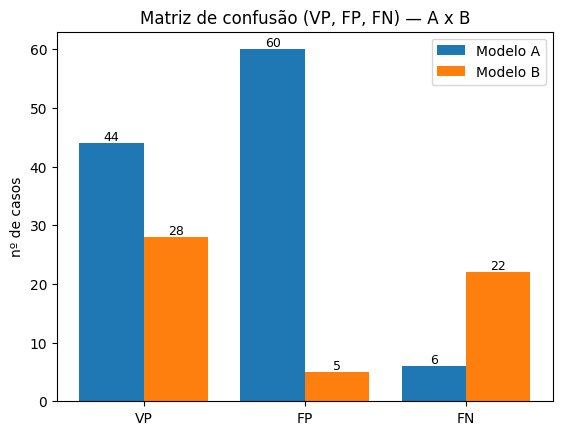

In [7]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
df = pd.read_csv("ex1_modelos.csv"); print(df.to_string(index=False))
cats=["VP","FP","FN"]; x=np.arange(3)   # os que importam para recall e precisao
A=df[df.modelo=="A"][cats].values[0]; B=df[df.modelo=="B"][cats].values[0]
plt.bar(x-0.2,A,0.4,label="Modelo A"); plt.bar(x+0.2,B,0.4,label="Modelo B")
for xi,(a,b) in enumerate(zip(A,B)):
    plt.text(xi-0.2,a+0.5,str(a),ha="center",fontsize=9); plt.text(xi+0.2,b+0.5,str(b),ha="center",fontsize=9)
plt.xticks(x,cats); plt.ylabel("nº de casos"); plt.title("Matriz de confusão (VP, FP, FN) — A x B"); plt.legend(); plt.show()

 Resposta A:

Dados dos Modelos:

*   Modelo A: VP = 44, FP = 60, FN = 6, VN = 440
*   Modelo B: VP = 28, FP = 5, FN = 22, VN = 495


a) Calcule o recall e a precisão de A e de B.


*   **Modelo A:**
    *   **Recall A = VP / (VP + FN)** = 44 / (44 + 6) = 44 / 50 = **0.88**
    *   **Precisão A = VP / (VP + FP)** = 44 / (44 + 60) = 44 / 104 ≈ **0.423**


*   **Modelo B:**
    *   **Recall B = VP / (VP + FN)** = 28 / (28 + 22) = 28 / 50 = **0.56**
    *   **Precisão B = VP / (VP + FP)** = 28 / (28 + 5) = 28 / 33 ≈ **0.84


 ----

 Respiosra B   


Eu escolheria o Modelo A. A justificativa se devev em relacaio aos erros abaixo:


- FN (falha não detectada): Causa uma parada cara (altcusto).
- FP (alarme falso): É barato (só uma checagem, baixo custo).

O Modelo A tem apenas **6 FNs**, enquanto o Modelo B tem **22 FNs**. Isso significa que o Modelo A é muito melhor em evitar as falhas caras que não são detectadas.

----

Reposta  C:

Para o Modelo "A" escolhido , o que importa é  maximizar o recall. Para isso, eu diminuiria o limiar  de classificação modelo,

- No Recall:

Diminuiria  o limiar fpara que o modelo seja mais 'liberal' em classificar um caso como positivo (falha).
 Isso significa que mais casos que são realmente falhas (positivos reais) serão corretamente identificados, convertendo alguns dos FNs restantes em VPs. Consequentemente, o **recall aumentaria**, pois o modelo detectaria uma proporção maior das falhas reais.

 ---


*   Na Precisão:

Como consequência de diminuir o limiar, o modelo também classifica mais casos como positivos que, na realidade, não são falhas . Isso aumenta o número de FPs . Assim,  a preciussao diminui , pois a proporção de previsões positivas que são verdadeiramente positivas seria menor. Contudo, essa troca é aceitável, pois o problema indica que o custo de um FP é baixo comparado ao de um FN.